In [1]:


diri = "/g/data/gv90/wrh581/NSIDC/"
fili = [diri+"NSIDC_SH_icearea_v06r00_197811-202512.nc",
     diri+"NSIDC_SH_icearea_v04r00_202601-202605.nc"]
iNam = "SIA"

diro  = "~/gd/Obs-seaice-analysis/plots/"



sector = {
        'Circumpolar' : {'minlon' : 0.,  'maxlon' : 360., 'minlat' : -70., 'maxlat' : -55},
        'E. hemisphere' : {'minlon' : 330., 'maxlon' : 90.,  'minlat' : -65., 'maxlat' : -55.},
        'E. Antarctic' : {'minlon' : 30., 'maxlon' : 90.,  'minlat' : -65., 'maxlat' : -60.},
        'Bellingshausen' : {'minlon' : 277.,  'maxlon' : 297.},
        'Weddell' : {'minlon' : 330., 'maxlon' : 30.}
}

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import xarray as xr
import pandas as pd

### read data

In [3]:
SIA = xr.open_mfdataset(fili)[iNam]

#add datetime array
dates = pd.date_range(
    
    start=pd.to_datetime(str(SIA['time'][0].values), format="%Y%m"),
    end=pd.to_datetime(str(SIA['time'].max().values), format="%Y%m"),
    freq="MS"
)

SIA['time'] = dates


### sector means

In [29]:
sector_SIA = xr.DataArray(np.empty([SIA.time.size, len(sector)]),
                          dims = ('time', 'sector'),
                          coords = {'time' : SIA.time, 'sector' : list(sector.keys())}
                         )

for sname in sector.keys():
    xmin = sector[sname]['minlon']
    xmax = sector[sname]['maxlon']
    loc_dict = {'sector' : sname}
    
    if xmin < xmax:
        sector_SIA.loc[loc_dict] = SIA.sel(lon = slice(xmin, xmax)).sum('lon')
    else:
        sector_SIA.loc[loc_dict] = SIA.where( (SIA.lon >= xmin) & (SIA.lon <= xmax)).sum('lon')

sector_SIA = (sector_SIA * 1.e-6).compute() #convert to million km2

sector_anom = anom = sector_SIA.groupby('time.month') - sector_SIA.sel(time = slice('1979','2018')).groupby('time.month').mean('time')

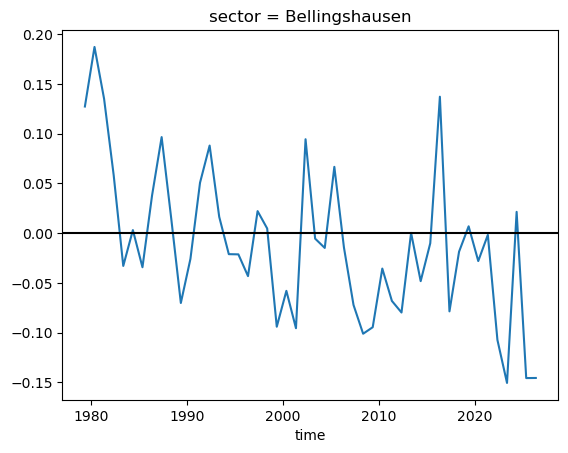

In [38]:
def plot_ts(plot_sec, plot_month):
    seldict = {'sector' : plot_sec,
               'time' : sector_anom.time.dt.month == plot_month }

    sector_anom.sel(**seldict).plot()
    plt.axhline(0., c='k')

plot_ts('Bellingshausen', 5)
